<a href="https://www.kaggle.com/code/jiayilin0414/dinov3?scriptVersionId=312028483" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
#获取数据集
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("DINOv3")
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
import os

# 从 Kaggle Secret 读取你的令牌
user_secrets = user_secrets
hf_token = secret_value_0

# 登录
login(token=hf_token)
print("✅ 已登录 Hugging Face")

In [4]:
#安装modelscope
!pip install modelscope

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 108.9 MB/s eta 0:00:0000:01


In [3]:
#输出特征图
import torch
import os
import math
from PIL import Image
from modelscope import AutoImageProcessor, AutoModel

# 1. 从 ModelScope 加载 DINOv3
print("正在从 ModelScope 加载 DINOv3 模型...")
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"✅ 模型加载完成！运行在: {device}")

# 2. 获取前10张图片
image_dir = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/JPEGImages/"
all_images = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))])[:10]
print(f"选取了 {len(all_images)} 张图片")

# 3. 批量提取特征
for img_file in all_images:
    img_path = os.path.join(image_dir, img_file)
    image = Image.open(img_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 获取特征
    if hasattr(outputs, 'last_hidden_state'):
        features = outputs.last_hidden_state
    else:
        features = outputs[0]
    
    # 去掉 [CLS] token，保留 patch tokens
    patch_tokens = features[:, 1:, :]
    batch_size, num_patches, feat_dim = patch_tokens.shape  # 从这里获取维度
    
    # 计算特征图尺寸
    h = int(math.sqrt(num_patches))
    while num_patches % h != 0:
        h -= 1
    w = num_patches // h
    
    # 重排成特征图
    feature_map = patch_tokens.transpose(1, 2).view(batch_size, feat_dim, h, w)
    
    print(f"✅ {img_file}: 原始 tokens={num_patches}, 特征图形状 {feature_map.shape}")

print("\n全部完成！")

正在从 ModelScope 加载 DINOv3 模型...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ 模型加载完成！运行在: cpu
选取了 10 张图片
✅ 2007_000027.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000032.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000033.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000039.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000042.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000061.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000063.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000068.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000121.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])
✅ 2007_000123.jpg: 原始 tokens=200, 特征图形状 torch.Size([1, 384, 10, 20])

全部完成！


正在从 ModelScope 加载 DINOv3 模型...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ 模型加载完成！运行在: cpu
选取了 4 张图片: ['2009_004568', '2011_001782', '2010_003547', '2010_001149']


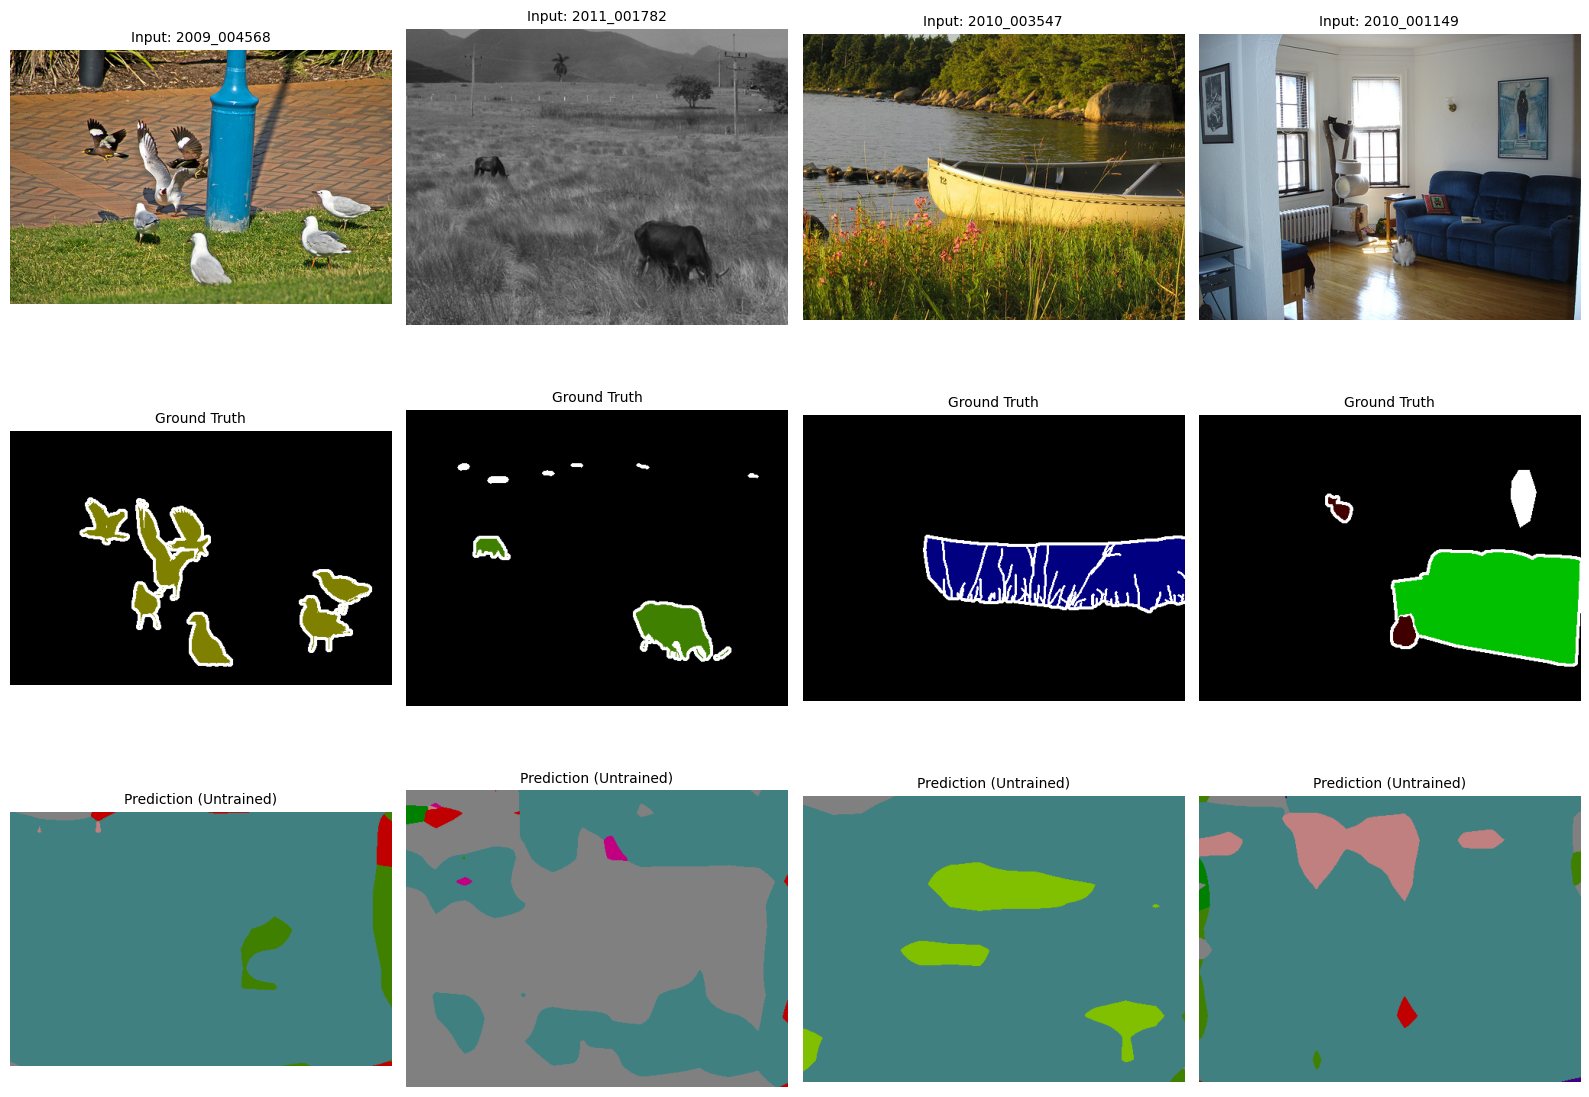


✅ 对比图已保存至 /kaggle/working/segmentation_untrained.png


In [4]:
#使用PSPNet进行语义分割测试
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from modelscope import AutoImageProcessor, AutoModel
import random

# ==================== 1. PSP 模块定义 ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


# ==================== 2. 完整 PSPNet 模型（随机初始化） ====================
class DINOv3_PSPNet(nn.Module):
    def __init__(self, backbone_model, num_classes=21):
        super().__init__()
        self.backbone = backbone_model
        self.hidden = 384
        self.patch = 16
        self.psp = PSPModule(self.hidden, sizes=(1, 2, 3, 6))
        self.head = nn.Sequential(
            nn.Conv2d(self.hidden * 5, 256, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, seq, B, N, C, H, W):
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, pixel_values):
        with torch.no_grad():
            outputs = self.backbone(pixel_values)
        
        if hasattr(outputs, 'last_hidden_state'):
            features = outputs.last_hidden_state
        else:
            features = outputs[0]
        
        B, N, C = features.shape
        H, W = pixel_values.shape[2], pixel_values.shape[3]
        feature_map = self._to_2d(features, B, N, C, H, W)
        y = self.psp(feature_map)
        y = self.head(y)
        y = F.interpolate(y, size=(H, W), mode="bilinear", align_corners=True)
        return y


# ==================== 3. VOC 调色板 ====================
VOC_PALETTE = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],[0,128,128],
    [128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],[64,0,128],[192,0,128],
    [64,128,128],[192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)


def colorize(mask):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    valid = (mask != 255)
    out[~valid] = [255, 255, 255]
    out[valid] = VOC_PALETTE[mask[valid]]
    return out


# ==================== 4. 加载 DINOv3 ====================
print("正在从 ModelScope 加载 DINOv3 模型...")
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone.to(device)
backbone.eval()

# 创建 PSPNet
model = DINOv3_PSPNet(backbone, num_classes=21).to(device)
model.eval()
print(f"✅ 模型加载完成！运行在: {device}")


# ==================== 5. 获取图片（带真值） ====================
image_dir = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/JPEGImages/"
mask_dir = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/SegmentationClass/"

# 从验证集中读取文件列表
split_file = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/ImageSets/Segmentation/val.txt"
with open(split_file, 'r') as f:
    val_files = [line.strip() for line in f.readlines()]

# 随机选 4 张
selected = random.sample(val_files, 4)
print(f"选取了 {len(selected)} 张图片: {selected}")


# ==================== 6. 推理并可视化 ====================
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, fname in enumerate(selected):
    # 加载图像
    img_path = os.path.join(image_dir, fname + ".jpg")
    image = Image.open(img_path).convert('RGB')
    orig_size = image.size
    
    # 预处理
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    # 推理
    with torch.no_grad():
        output = model(inputs['pixel_values'])
        output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    # 加载真值
    mask_path = os.path.join(mask_dir, fname + ".png")
    gt = np.array(Image.open(mask_path))
    gt[gt == 255] = 255
    
    # 第一行：输入原图
    axes[0, i].imshow(image)
    axes[0, i].set_title(f'Input: {fname}', fontsize=10)
    axes[0, i].axis('off')
    
    # 第二行：真值
    axes[1, i].imshow(colorize(gt))
    axes[1, i].set_title('Ground Truth', fontsize=10)
    axes[1, i].axis('off')
    
    # 第三行：预测（随机初始化）
    axes[2, i].imshow(colorize(pred))
    axes[2, i].set_title('Prediction (Untrained)', fontsize=10)
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/segmentation_untrained.png', dpi=150)
plt.show()
print("\n✅ 对比图已保存至 /kaggle/working/segmentation_untrained.png")

使用设备: cuda
训练集: 1464 张, 验证集: 1449 张


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

/tmp/ipykernel_55/2933105685.py:297: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device=="cuda"))
Training:   0%|          | 0/366 [00:00<?, ?it/s]/tmp/ipykernel_55/2933105685.py:225: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):
Validating: 100%|██████████| 363/363 [00:17<00:00, 20.72it/s]


Epoch 1/60 | Train Loss: 3.2569 | Val mIoU: 0.0035
✅ 保存最优模型 (mIoU: 0.0035)


Validating: 100%|██████████| 363/363 [00:17<00:00, 20.83it/s]


...

Epoch 58/60 | Train Loss: 0.1952 | Val mIoU: 0.6579


Validating: 100%|██████████| 363/363 [00:16<00:00, 21.67it/s]


Epoch 59/60 | Train Loss: 0.1955 | Val mIoU: 0.6568


Validating: 100%|██████████| 363/363 [00:16<00:00, 21.79it/s]


Epoch 60/60 | Train Loss: 0.1939 | Val mIoU: 0.6563

训练完成！最优 mIoU: 0.6612


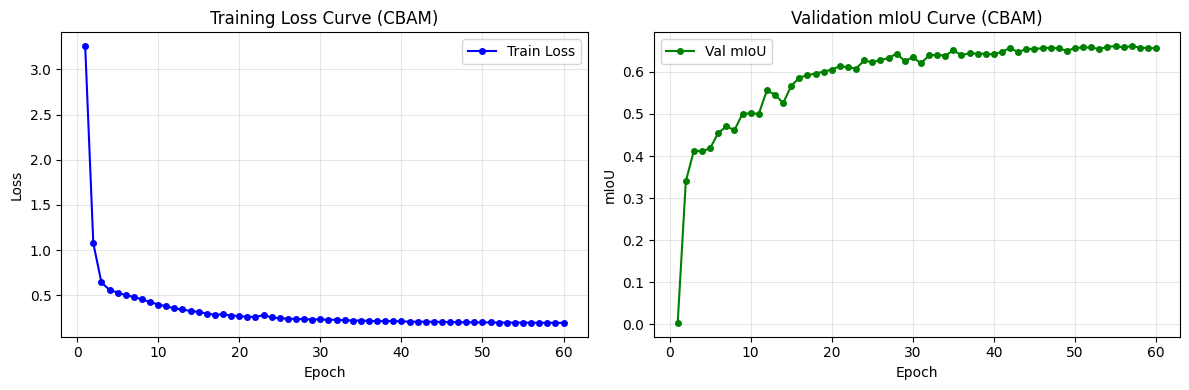

✅ 训练曲线已保存至 /kaggle/working/training_curves_cbam.png


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import os
import math
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from modelscope import AutoModel
import random
import cv2
from albumentations import Compose, HorizontalFlip, Normalize, RandomResizedCrop, ColorJitter, Blur, Resize
from albumentations.pytorch import ToTensorV2

# ==================== 1. 工具函数 ====================
def dice_loss(logits, target, ignore_index=255, eps=1e-6):
    """标准多类 Dice Loss"""
    probs = torch.softmax(logits, dim=1)
    num_classes = probs.shape[1]
    valid = (target != ignore_index)
    target_valid = torch.where(valid, target, torch.zeros_like(target))
    onehot = F.one_hot(target_valid, num_classes=num_classes).permute(0,3,1,2).float()
    valid = valid.unsqueeze(1).float()
    probs = probs * valid
    onehot = onehot * valid
    inter = (probs * onehot).sum(dim=(0,2,3))
    denom = probs.sum(dim=(0,2,3)) + onehot.sum(dim=(0,2,3))
    dice = (2 * inter + eps) / (denom + eps)
    return 1 - dice.mean()


def mean_iou(logits, target, num_classes=21, ignore_index=255):
    """计算 mIoU"""
    pred = torch.argmax(logits, dim=1)
    valid = (target != ignore_index)
    ious = []
    for cls in range(num_classes):
        pred_c = (pred == cls) & valid
        tgt_c  = (target == cls) & valid
        inter = (pred_c & tgt_c).sum().float()
        union = (pred_c | tgt_c).sum().float()
        if union > 0:
            ious.append(inter / union)
    if len(ious) == 0:
        return torch.tensor(0.0, device=logits.device)
    return torch.stack(ious).mean()

# CBAM 模块完整代码 (PyTorch)
import torch
from torch import nn

class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.maxpool = nn.AdaptiveMaxPool2d(1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        # 共享MLP
        self.se = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result = self.maxpool(x)
        avg_result = self.avgpool(x)
        max_out = self.se(max_result)
        avg_out = self.se(avg_result)
        output = self.sigmoid(max_out + avg_out)
        return output

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result, _ = torch.max(x, dim=1, keepdim=True)
        avg_result = torch.mean(x, dim=1, keepdim=True)
        result = torch.cat([max_result, avg_result], dim=1)
        output = self.conv(result)
        output = self.sigmoid(output)
        return output

class CBAM(nn.Module):
    def __init__(self, channel, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        # 先通道注意力，再空间注意力
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out
        
# ==================== 2. 金字塔池化模块 ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


# ==================== 3. PSPNet 模型（修正特征提取） ====================
class DINOv3_PSPNet(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch  = int(getattr(self.backbone.config, "patch_size", 16))
        self.psp  = PSPModule(self.hidden, sizes=(1, 2, 3, 6))
        self.cbam = CBAM(self.hidden)
        self.head = nn.Sequential(
            nn.Conv2d(self.hidden * 5, 256, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        """精确提取 patch tokens，跳过 [CLS] 和 register tokens"""
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        
        y = self.cbam(feat2d)       # 先 CBAM，输入 384 通道
        y = self.psp(y)             # 再 PPM，输出 1920 通道
        y = self.head(y)
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y


# ==================== 4. VOC 数据集（增强版） ====================
class VOCDataset(Dataset):
    def __init__(self, root, split='train', size=320, num_classes=21):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.mask_dir = os.path.join(root, "SegmentationClass")
        split_file = os.path.join(root, "ImageSets", "Segmentation", split + ".txt")
        with open(split_file, "r") as f:
            self.filenames = [x.strip() for x in f]
        self.size = size
        self.num_classes = num_classes
        
        if split == 'train':
            self.transform = Compose([
                RandomResizedCrop(size=(size, size), scale=(0.5, 1.0), ratio=(0.9, 1.1), interpolation=cv2.INTER_LINEAR),
                HorizontalFlip(p=0.5),
                ColorJitter(p=0.3, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                Blur(p=0.1, blur_limit=3),
                Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = Compose([
                Resize(height=size, width=size, interpolation=cv2.INTER_LINEAR),
                Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path  = os.path.join(self.img_dir,  fname + ".jpg")
        mask_path = os.path.join(self.mask_dir, fname + ".png")
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = np.array(Image.open(mask_path))
        mask = mask.copy()
        mask[(mask >= self.num_classes) & (mask != 255)] = 255
        data = self.transform(image=img, mask=mask)
        img  = data["image"]
        mask = data["mask"]
        mask = torch.as_tensor(mask, dtype=torch.long)
        return img, mask


# ==================== 5. 训练函数 ====================
def train_one_epoch(model, loader, optimizer, criterion, device, scaler, accum_steps):
    model.train()
    total_loss = 0
    optimizer.zero_grad(set_to_none=True)
    for it, (imgs, masks) in enumerate(tqdm(loader, desc='Training'), 1):
        imgs, masks = imgs.to(device), masks.to(device)
        with autocast(enabled=(device=="cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks) + 0.2 * dice_loss(logits, masks, ignore_index=255)
        loss = loss / accum_steps
        scaler.scale(loss).backward()
        if it % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * accum_steps
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_miou = 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Validating'):
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            total_miou += mean_iou(logits, masks, ignore_index=255).item()
    return total_miou / len(loader)


# ==================== 6. 主训练流程 ====================
def main():
    torch.backends.cudnn.benchmark = True
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    VOC_ROOT = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
    BATCH_SIZE = 4
    NUM_EPOCHS = 60
    FREEZE_EPOCHS = 8
    ACCUM_STEPS = 1
    NUM_CLASSES = 21
    
    print(f"使用设备: {device}")
    
    # 数据加载
    train_set = VOCDataset(VOC_ROOT, split='train', size=320)
    val_set = VOCDataset(VOC_ROOT, split='val', size=320)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f"训练集: {len(train_set)} 张, 验证集: {len(val_set)} 张")
    
    # 模型
    model = DINOv3_PSPNet(num_classes=NUM_CLASSES).to(device)
    
    # 初始冻结 backbone
    for p in model.backbone.parameters():
        p.requires_grad = False
    
    backbone_params = [p for n, p in model.named_parameters() if n.startswith("backbone.")]
    head_params = [p for n, p in model.named_parameters() if not n.startswith("backbone.")]
    
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": 1e-5, "weight_decay": 0.01},
        {"params": head_params,    "lr": 1e-3, "weight_decay": 0.01},
    ])
    
    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps = NUM_EPOCHS * steps_per_epoch
    warmup_steps = int(0.1 * total_steps)
    
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(ignore_index=255).to(device)
    scaler = GradScaler(enabled=(device=="cuda"))
    
    best_miou = 0.0
    step = 0

    train_losses = []
    val_mious = []
    
    for epoch in range(1, NUM_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print("\n🔓 解冻 backbone，开始联合微调...")
            for p in model.backbone.parameters():
                p.requires_grad = True
        
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler, ACCUM_STEPS)
        val_miou = validate(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_mious.append(val_miou)
        # 手动更新 scheduler（按 step）
        for _ in range(steps_per_epoch):
            scheduler.step()
            step += 1
        
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val mIoU: {val_miou:.4f}")
        
        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(model.state_dict(), '/kaggle/working/best_pspnet_cbam.pth')
            print(f"✅ 保存最优模型 (mIoU: {best_miou:.4f})")
    
    print(f"\n训练完成！最优 mIoU: {best_miou:.4f}")
    
    epochs = list(range(1, NUM_EPOCHS + 1))
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', markersize=4, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve (CBAM)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_mious, 'g-o', markersize=4, label='Val mIoU')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.title('Validation mIoU Curve (CBAM)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves_cbam.png', dpi=150)
    plt.show()
    print("✅ 训练曲线已保存至 /kaggle/working/training_curves_cbam.png")
if __name__ == "__main__":
    main()

使用设备: cuda
训练集: 1464 张, 验证集: 1449 张


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

/tmp/ipykernel_55/2495095091.py:392: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device=="cuda"))
Training:   0%|          | 0/183 [00:00<?, ?it/s]/tmp/ipykernel_55/2495095091.py:320: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):
Validating: 100%|██████████| 182/182 [00:19<00:00,  9.29it/s]


Epoch 1/60 | Train Loss: 3.1625 | Val mIoU: 0.0071
✅ 保存最优模型 (mIoU: 0.0071)


Validating: 100%|██████████| 182/182 [00:18<00:00,  9.78it/s]


...

Epoch 58/60 | Train Loss: 0.1466 | Val mIoU: 0.6987


Validating: 100%|██████████| 182/182 [00:18<00:00,  9.96it/s]


Epoch 59/60 | Train Loss: 0.1464 | Val mIoU: 0.7021


Validating: 100%|██████████| 182/182 [00:18<00:00,  9.97it/s]


Epoch 60/60 | Train Loss: 0.1467 | Val mIoU: 0.7036

训练完成！最优 mIoU: 0.7091


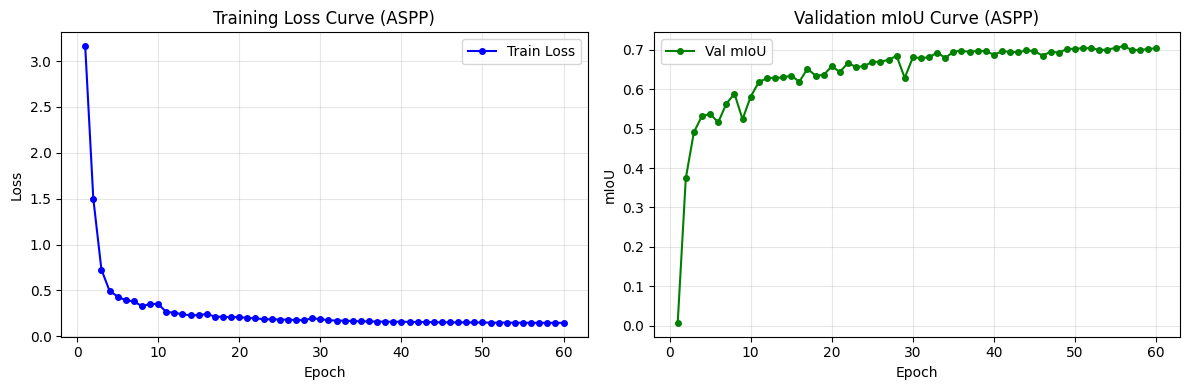

✅ 训练曲线已保存至 /kaggle/working/training_curves_aspp.png


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import os
import math
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from modelscope import AutoModel
import random
import cv2
from albumentations import Compose, HorizontalFlip, Normalize, RandomResizedCrop, ColorJitter, Blur, Resize
from albumentations.pytorch import ToTensorV2

# ==================== 1. 工具函数 ====================
def dice_loss(logits, target, ignore_index=255, eps=1e-6):
    """标准多类 Dice Loss"""
    probs = torch.softmax(logits, dim=1)
    num_classes = probs.shape[1]
    valid = (target != ignore_index)
    target_valid = torch.where(valid, target, torch.zeros_like(target))
    onehot = F.one_hot(target_valid, num_classes=num_classes).permute(0,3,1,2).float()
    valid = valid.unsqueeze(1).float()
    probs = probs * valid
    onehot = onehot * valid
    inter = (probs * onehot).sum(dim=(0,2,3))
    denom = probs.sum(dim=(0,2,3)) + onehot.sum(dim=(0,2,3))
    dice = (2 * inter + eps) / (denom + eps)
    return 1 - dice.mean()


def mean_iou(logits, target, num_classes=21, ignore_index=255):
    """计算 mIoU"""
    pred = torch.argmax(logits, dim=1)
    valid = (target != ignore_index)
    ious = []
    for cls in range(num_classes):
        pred_c = (pred == cls) & valid
        tgt_c  = (target == cls) & valid
        inter = (pred_c & tgt_c).sum().float()
        union = (pred_c | tgt_c).sum().float()
        if union > 0:
            ious.append(inter / union)
    if len(ious) == 0:
        return torch.tensor(0.0, device=logits.device)
    return torch.stack(ious).mean()

# CBAM 模块完整代码 (PyTorch)
class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.maxpool = nn.AdaptiveMaxPool2d(1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        # 共享MLP
        self.se = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result = self.maxpool(x)
        avg_result = self.avgpool(x)
        max_out = self.se(max_result)
        avg_out = self.se(avg_result)
        output = self.sigmoid(max_out + avg_out)
        return output

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result, _ = torch.max(x, dim=1, keepdim=True)
        avg_result = torch.mean(x, dim=1, keepdim=True)
        result = torch.cat([max_result, avg_result], dim=1)
        output = self.conv(result)
        output = self.sigmoid(output)
        return output

class CBAM(nn.Module):
    def __init__(self, channel, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        # 先通道注意力，再空间注意力
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out
        
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==================== ASPP 模块 ====================
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels, dilations=(6, 12, 18)):
        super().__init__()
        
        # 1x1 卷积分支
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # 空洞卷积分支
        self.aspp_modules = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for d in dilations
        ])
        
        # 全局平均池化分支
        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # 融合卷积
        num_branches = 1 + len(dilations) + 1  # 1x1 + 空洞卷积分支 + 全局池化
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * num_branches, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        
    def forward(self, x):
        h, w = x.shape[2:]
        
        # 1x1 卷积
        out1x1 = self.conv1x1(x)
        
        # 空洞卷积
        aspp_outs = [out1x1]
        for module in self.aspp_modules:
            aspp_outs.append(module(x))
        
        # 全局平均池化 + 上采样
        global_out = self.global_avg_pool(x)
        global_out = F.interpolate(global_out, size=(h, w), mode='bilinear', align_corners=True)
        aspp_outs.append(global_out)
        
        # 拼接所有分支
        out = torch.cat(aspp_outs, dim=1)
        return self.fusion(out)


# ==================== PPM 模块（保持不变） ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


# ==================== ASPP + PPM 并联融合模块 ====================
class ASPP_PPM_Fusion(nn.Module):
    def __init__(self, in_channels, aspp_out_channels=256, dilations=(6, 12, 18)):
        super().__init__()
        
        # ASPP 分支
        self.aspp = ASPP(in_channels, aspp_out_channels, dilations)
        
        # PPM 分支
        self.ppm = PSPModule(in_channels, sizes=(1, 2, 3, 6))
        ppm_out_channels = in_channels * 5  # PPM 输出通道数（原始 + 4个池化分支）
        
        # 融合卷积
        total_channels = aspp_out_channels + ppm_out_channels
        self.fusion = nn.Sequential(
            nn.Conv2d(total_channels, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        
    def forward(self, x):
        aspp_out = self.aspp(x)      # [B, 256, H, W]
        ppm_out = self.ppm(x)        # [B, in_channels*5, H, W]
        out = torch.cat([aspp_out, ppm_out], dim=1)
        return self.fusion(out)


# ==================== 完整模型（DINOv3 + ASPP+PPM） ====================
class DINOv3_PSPNet_ASPP(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
        from modelscope import AutoModel
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch = int(getattr(self.backbone.config, "patch_size", 16))
        
        # CBAM 注意力（可选，建议保留）
        self.cbam = CBAM(self.hidden)
        
        # ASPP + PPM 并联模块
        self.fusion_module = ASPP_PPM_Fusion(self.hidden, aspp_out_channels=256)
        
        # 分类头
        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        y = self.cbam(feat2d)              # CBAM 注意力
        y = self.fusion_module(y)          # ASPP + PPM 并联融合
        y = self.head(y)                   # 分类
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y


# ==================== 4. VOC 数据集（增强版） ====================
class VOCDataset(Dataset):
    def __init__(self, root, split='train', size=320, num_classes=21):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.mask_dir = os.path.join(root, "SegmentationClass")
        split_file = os.path.join(root, "ImageSets", "Segmentation", split + ".txt")
        with open(split_file, "r") as f:
            self.filenames = [x.strip() for x in f]
        self.size = size
        self.num_classes = num_classes
        
        if split == 'train':
            self.transform = Compose([
                RandomResizedCrop(size=(size, size), scale=(0.5, 1.0), ratio=(0.9, 1.1), interpolation=cv2.INTER_LINEAR),
                HorizontalFlip(p=0.5),
                ColorJitter(p=0.3, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                Blur(p=0.1, blur_limit=3),
                Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = Compose([
                Resize(height=size, width=size, interpolation=cv2.INTER_LINEAR),
                Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path  = os.path.join(self.img_dir,  fname + ".jpg")
        mask_path = os.path.join(self.mask_dir, fname + ".png")
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = np.array(Image.open(mask_path))
        mask = mask.copy()
        mask[(mask >= self.num_classes) & (mask != 255)] = 255
        data = self.transform(image=img, mask=mask)
        img  = data["image"]
        mask = data["mask"]
        mask = torch.as_tensor(mask, dtype=torch.long)
        return img, mask


# ==================== 5. 训练函数 ====================
def train_one_epoch(model, loader, optimizer, criterion, device, scaler, accum_steps):
    model.train()
    total_loss = 0
    optimizer.zero_grad(set_to_none=True)
    for it, (imgs, masks) in enumerate(tqdm(loader, desc='Training'), 1):
        imgs, masks = imgs.to(device), masks.to(device)
        with autocast(enabled=(device=="cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks) + 0.2 * dice_loss(logits, masks, ignore_index=255)
        loss = loss / accum_steps
        scaler.scale(loss).backward()
        if it % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * accum_steps
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_miou = 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Validating'):
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            total_miou += mean_iou(logits, masks, ignore_index=255).item()
    return total_miou / len(loader)


# ==================== 6. 主训练流程 ====================
def main():
    torch.backends.cudnn.benchmark = True
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    VOC_ROOT = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
    BATCH_SIZE = 8
    NUM_EPOCHS = 60
    FREEZE_EPOCHS = 8
    ACCUM_STEPS = 1
    NUM_CLASSES = 21
    
    print(f"使用设备: {device}")
    
    # 数据加载
    train_set = VOCDataset(VOC_ROOT, split='train', size=320)
    val_set = VOCDataset(VOC_ROOT, split='val', size=320)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f"训练集: {len(train_set)} 张, 验证集: {len(val_set)} 张")
    
    # 模型
    model = DINOv3_PSPNet_ASPP(num_classes=NUM_CLASSES).to(device)
    
    # 初始冻结 backbone
    for p in model.backbone.parameters():
        p.requires_grad = False
    
    backbone_params = [p for n, p in model.named_parameters() if n.startswith("backbone.")]
    head_params = [p for n, p in model.named_parameters() if not n.startswith("backbone.")]
    
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": 5e-5, "weight_decay": 0.01},
        {"params": head_params,    "lr": 5e-4, "weight_decay": 0.01},
    ])
    
    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps = NUM_EPOCHS * steps_per_epoch
    warmup_steps = int(0.1 * total_steps)
    
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(ignore_index=255).to(device)
    scaler = GradScaler(enabled=(device=="cuda"))
    
    best_miou = 0.0
    step = 0

    train_losses = []
    val_mious = []
    
    for epoch in range(1, NUM_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print("\n🔓 解冻 backbone，开始联合微调...")
            for p in model.backbone.parameters():
                p.requires_grad = True
        
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler, ACCUM_STEPS)
        val_miou = validate(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_mious.append(val_miou)
        # 手动更新 scheduler（按 step）
        for _ in range(steps_per_epoch):
            scheduler.step()
            step += 1
        
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val mIoU: {val_miou:.4f}")
        
        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(model.state_dict(), '/kaggle/working/best_pspnet_aspp.pth')
            print(f"✅ 保存最优模型 (mIoU: {best_miou:.4f})")
    
    print(f"\n训练完成！最优 mIoU: {best_miou:.4f}")
    
    epochs = list(range(1, NUM_EPOCHS + 1))
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', markersize=4, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve (ASPP)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_mious, 'g-o', markersize=4, label='Val mIoU')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.title('Validation mIoU Curve (ASPP)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves_aspp.png', dpi=150)
    plt.show()
    print("✅ 训练曲线已保存至 /kaggle/working/training_curves_aspp.png")
if __name__ == "__main__":
    main()

In [ ]:
#改进：增大尺寸
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import os
import math
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from modelscope import AutoModel
import random
import cv2
from albumentations import Compose, HorizontalFlip, Normalize, RandomResizedCrop, ColorJitter, Blur, Resize
from albumentations.pytorch import ToTensorV2

# ==================== 1. 工具函数 ====================
def dice_loss(logits, target, ignore_index=255, eps=1e-6):
    """标准多类 Dice Loss"""
    probs = torch.softmax(logits, dim=1)
    num_classes = probs.shape[1]
    valid = (target != ignore_index)
    target_valid = torch.where(valid, target, torch.zeros_like(target))
    onehot = F.one_hot(target_valid, num_classes=num_classes).permute(0,3,1,2).float()
    valid = valid.unsqueeze(1).float()
    probs = probs * valid
    onehot = onehot * valid
    inter = (probs * onehot).sum(dim=(0,2,3))
    denom = probs.sum(dim=(0,2,3)) + onehot.sum(dim=(0,2,3))
    dice = (2 * inter + eps) / (denom + eps)
    return 1 - dice.mean()


def mean_iou(logits, target, num_classes=21, ignore_index=255):
    """计算 mIoU"""
    pred = torch.argmax(logits, dim=1)
    valid = (target != ignore_index)
    ious = []
    for cls in range(num_classes):
        pred_c = (pred == cls) & valid
        tgt_c  = (target == cls) & valid
        inter = (pred_c & tgt_c).sum().float()
        union = (pred_c | tgt_c).sum().float()
        if union > 0:
            ious.append(inter / union)
    if len(ious) == 0:
        return torch.tensor(0.0, device=logits.device)
    return torch.stack(ious).mean()

# CBAM 模块完整代码 (PyTorch)
class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.maxpool = nn.AdaptiveMaxPool2d(1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        # 共享MLP
        self.se = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result = self.maxpool(x)
        avg_result = self.avgpool(x)
        max_out = self.se(max_result)
        avg_out = self.se(avg_result)
        output = self.sigmoid(max_out + avg_out)
        return output

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result, _ = torch.max(x, dim=1, keepdim=True)
        avg_result = torch.mean(x, dim=1, keepdim=True)
        result = torch.cat([max_result, avg_result], dim=1)
        output = self.conv(result)
        output = self.sigmoid(output)
        return output

class CBAM(nn.Module):
    def __init__(self, channel, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        # 先通道注意力，再空间注意力
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out
        
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==================== ASPP 模块 ====================
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels, dilations=(6, 12, 18)):
        super().__init__()
        
        # 1x1 卷积分支
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # 空洞卷积分支
        self.aspp_modules = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for d in dilations
        ])
        
        # 全局平均池化分支
        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # 融合卷积
        num_branches = 1 + len(dilations) + 1  # 1x1 + 空洞卷积分支 + 全局池化
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * num_branches, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        
    def forward(self, x):
        h, w = x.shape[2:]
        
        # 1x1 卷积
        out1x1 = self.conv1x1(x)
        
        # 空洞卷积
        aspp_outs = [out1x1]
        for module in self.aspp_modules:
            aspp_outs.append(module(x))
        
        # 全局平均池化 + 上采样
        global_out = self.global_avg_pool(x)
        global_out = F.interpolate(global_out, size=(h, w), mode='bilinear', align_corners=True)
        aspp_outs.append(global_out)
        
        # 拼接所有分支
        out = torch.cat(aspp_outs, dim=1)
        return self.fusion(out)


# ==================== PPM 模块（保持不变） ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


# ==================== ASPP + PPM 并联融合模块 ====================
class ASPP_PPM_Fusion(nn.Module):
    def __init__(self, in_channels, aspp_out_channels=256, dilations=(6, 12, 18)):
        super().__init__()
        
        # ASPP 分支
        self.aspp = ASPP(in_channels, aspp_out_channels, dilations)
        
        # PPM 分支
        self.ppm = PSPModule(in_channels, sizes=(1, 2, 3, 6))
        ppm_out_channels = in_channels * 5  # PPM 输出通道数（原始 + 4个池化分支）
        
        # 融合卷积
        total_channels = aspp_out_channels + ppm_out_channels
        self.fusion = nn.Sequential(
            nn.Conv2d(total_channels, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        
    def forward(self, x):
        aspp_out = self.aspp(x)      # [B, 256, H, W]
        ppm_out = self.ppm(x)        # [B, in_channels*5, H, W]
        out = torch.cat([aspp_out, ppm_out], dim=1)
        return self.fusion(out)


# ==================== 完整模型（DINOv3 + ASPP+PPM） ====================
class DINOv3_PSPNet_ASPP(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
        from modelscope import AutoModel
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch = int(getattr(self.backbone.config, "patch_size", 16))
        
        # CBAM 注意力（可选，建议保留）
        self.cbam = CBAM(self.hidden)
        
        # ASPP + PPM 并联模块
        self.fusion_module = ASPP_PPM_Fusion(self.hidden, aspp_out_channels=256)
        
        # 分类头
        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        y = self.cbam(feat2d)              # CBAM 注意力
        y = self.fusion_module(y)          # ASPP + PPM 并联融合
        y = self.head(y)                   # 分类
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y


# ==================== 4. VOC 数据集（增强版） ====================
class VOCDataset(Dataset):
    def __init__(self, root, split='train', size=320, num_classes=21):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.mask_dir = os.path.join(root, "SegmentationClass")
        split_file = os.path.join(root, "ImageSets", "Segmentation", split + ".txt")
        with open(split_file, "r") as f:
            self.filenames = [x.strip() for x in f]
        self.size = size
        self.num_classes = num_classes
        
        if split == 'train':
            self.transform = Compose([
                RandomResizedCrop(size=(size, size), scale=(0.5, 1.0), ratio=(0.9, 1.1), interpolation=cv2.INTER_LINEAR),
                HorizontalFlip(p=0.5),
                ColorJitter(p=0.3, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                Blur(p=0.1, blur_limit=3),
                Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = Compose([
                Resize(height=size, width=size, interpolation=cv2.INTER_LINEAR),
                Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path  = os.path.join(self.img_dir,  fname + ".jpg")
        mask_path = os.path.join(self.mask_dir, fname + ".png")
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = np.array(Image.open(mask_path))
        mask = mask.copy()
        mask[(mask >= self.num_classes) & (mask != 255)] = 255
        data = self.transform(image=img, mask=mask)
        img  = data["image"]
        mask = data["mask"]
        mask = torch.as_tensor(mask, dtype=torch.long)
        return img, mask


# ==================== 5. 训练函数 ====================
def train_one_epoch(model, loader, optimizer, criterion, device, scaler, accum_steps):
    model.train()
    total_loss = 0
    optimizer.zero_grad(set_to_none=True)
    for it, (imgs, masks) in enumerate(tqdm(loader, desc='Training'), 1):
        imgs, masks = imgs.to(device), masks.to(device)
        with autocast(enabled=(device=="cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks) + 0.2 * dice_loss(logits, masks, ignore_index=255)
        loss = loss / accum_steps
        scaler.scale(loss).backward()
        if it % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * accum_steps
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_miou = 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Validating'):
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            total_miou += mean_iou(logits, masks, ignore_index=255).item()
    return total_miou / len(loader)


# ==================== 6. 主训练流程 ====================
def main():
    torch.backends.cudnn.benchmark = True
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    VOC_ROOT = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
    BATCH_SIZE = 8
    NUM_EPOCHS = 60
    FREEZE_EPOCHS = 8
    ACCUM_STEPS = 1
    NUM_CLASSES = 21
    
    print(f"使用设备: {device}")
    
    # 数据加载
    train_set = VOCDataset(VOC_ROOT, split='train', size=320)
    val_set = VOCDataset(VOC_ROOT, split='val', size=320)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f"训练集: {len(train_set)} 张, 验证集: {len(val_set)} 张")
    
    # 模型
    model = DINOv3_PSPNet_ASPP(num_classes=NUM_CLASSES).to(device)
    
    # 初始冻结 backbone
    for p in model.backbone.parameters():
        p.requires_grad = False
    
    backbone_params = [p for n, p in model.named_parameters() if n.startswith("backbone.")]
    head_params = [p for n, p in model.named_parameters() if not n.startswith("backbone.")]
    
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": 5e-5, "weight_decay": 0.01},
        {"params": head_params,    "lr": 5e-4, "weight_decay": 0.01},
    ])
    
    steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
    total_steps = NUM_EPOCHS * steps_per_epoch
    warmup_steps = int(0.1 * total_steps)
    
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(ignore_index=255).to(device)
    scaler = GradScaler(enabled=(device=="cuda"))
    
    best_miou = 0.0
    step = 0

    train_losses = []
    val_mious = []
    
    for epoch in range(1, NUM_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print("\n🔓 解冻 backbone，开始联合微调...")
            for p in model.backbone.parameters():
                p.requires_grad = True
        
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler, ACCUM_STEPS)
        val_miou = validate(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_mious.append(val_miou)
        # 手动更新 scheduler（按 step）
        for _ in range(steps_per_epoch):
            scheduler.step()
            step += 1
        
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val mIoU: {val_miou:.4f}")
        
        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(model.state_dict(), '/kaggle/working/best_pspnet_aspp.pth')
            print(f"✅ 保存最优模型 (mIoU: {best_miou:.4f})")
    
    print(f"\n训练完成！最优 mIoU: {best_miou:.4f}")
    
    epochs = list(range(1, NUM_EPOCHS + 1))
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', markersize=4, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve (ASPP)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_mious, 'g-o', markersize=4, label='Val mIoU')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.title('Validation mIoU Curve (ASPP)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves_aspp.png', dpi=150)
    plt.show()
    print("✅ 训练曲线已保存至 /kaggle/working/training_curves_aspp.png")
if __name__ == "__main__":
    main()

In [13]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random
from torchvision import transforms
from modelscope import AutoModel
import torch.nn as nn

# ==================== 模型定义（使用 ModelScope） ====================
HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)

class DINOv3_PSPNet(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch  = int(getattr(self.backbone.config, "patch_size", 16))
        self.psp  = PSPModule(self.hidden, sizes=(1, 2, 3, 6))
        self.head = nn.Sequential(
            nn.Conv2d(self.hidden * 5, 256, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        y = self.psp(feat2d)
        y = self.head(y)
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y

# ==================== 配置路径 ====================
VOC_ROOT   = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
CKPT_PATH  = "/kaggle/working/best_pspnet.pth"
OUT_DIR    = "/kaggle/working/report_figs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "overlays"), exist_ok=True)

# VOC 类别名称
CLASS_NAMES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus',
    'car','cat','chair','cow','diningtable','dog','horse','motorbike',
    'person','pottedplant','sheep','sofa','train','tvmonitor'
]
NUM_CLASSES = 21
IGNORE = 255

# VOC 调色板
VOC_PALETTE = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],[0,128,128],
    [128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],[64,0,128],[192,0,128],
    [64,128,128],[192,128,128],[0,64,0],[128,64,0],[0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

def colorize(mask):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    valid = (mask != IGNORE)
    out[~valid] = [255, 255, 255]
    out[valid] = VOC_PALETTE[mask[valid]]
    return out

def overlay(img_np, mask_np, alpha=0.5):
    color = colorize(mask_np).astype(np.float32) / 255.0
    return np.clip((1 - alpha) * img_np + alpha * color, 0, 1)

# ==================== 加载模型 ====================
device = "cuda" if torch.cuda.is_available() else "cpu"
model = DINOv3_PSPNet(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print("✅ 模型加载完成")

# ==================== 加载验证集 ====================
img_dir = os.path.join(VOC_ROOT, "JPEGImages")
mask_dir = os.path.join(VOC_ROOT, "SegmentationClass")
split_file = os.path.join(VOC_ROOT, "ImageSets", "Segmentation", "val.txt")
with open(split_file, "r") as f:
    val_files = [x.strip() for x in f.readlines()]

print(f"验证集图片数: {len(val_files)}")

transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==================== 1. 生成定性对比网格 ====================
print("\n📊 生成定性对比网格...")
sample_files = random.sample(val_files, min(6, len(val_files)))

fig, axes = plt.subplots(3, len(sample_files), figsize=(4*len(sample_files), 12))
for i, fname in enumerate(sample_files):
    img_path = os.path.join(img_dir, fname + ".jpg")
    mask_path = os.path.join(mask_dir, fname + ".png")
    
    image = Image.open(img_path).convert('RGB')
    orig_size = image.size
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    gt = np.array(Image.open(mask_path))
    gt[gt == 255] = IGNORE
    
    axes[0, i].imshow(image)
    axes[0, i].set_title(f'Input', fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(colorize(gt))
    axes[1, i].set_title(f'Ground Truth', fontsize=10)
    axes[1, i].axis('off')
    
    axes[2, i].imshow(colorize(pred))
    axes[2, i].set_title(f'Prediction', fontsize=10)
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "qualitative_grid.png"), dpi=150)
plt.show()
print(f"✅ 定性网格已保存至 {os.path.join(OUT_DIR, 'qualitative_grid.png')}")

# ==================== 2. 生成叠加对比图 ====================
print("\n📊 生成叠加对比图...")
overlay_files = random.sample(val_files, min(4, len(val_files)))

fig, axes = plt.subplots(2, len(overlay_files), figsize=(4*len(overlay_files), 8))
for i, fname in enumerate(overlay_files):
    img_path = os.path.join(img_dir, fname + ".jpg")
    mask_path = os.path.join(mask_dir, fname + ".png")
    
    image = Image.open(img_path).convert('RGB')
    orig_size = image.size
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    gt = np.array(Image.open(mask_path))
    gt[gt == 255] = IGNORE
    
    img_np = np.array(image) / 255.0
    pred_overlay = overlay(img_np, pred, alpha=0.5)
    gt_overlay = overlay(img_np, gt, alpha=0.5)
    
    axes[0, i].imshow(gt_overlay)
    axes[0, i].set_title(f'GT Overlay', fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(pred_overlay)
    axes[1, i].set_title(f'Pred Overlay', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "overlay_comparison.png"), dpi=150)
plt.show()
print(f"✅ 叠加对比图已保存至 {os.path.join(OUT_DIR, 'overlay_comparison.png')}")

# ==================== 3. 计算每类 IoU 和混淆矩阵 ====================
print("\n📊 计算每类 IoU 和混淆矩阵...")
conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

with torch.no_grad():
    for fname in tqdm(val_files[:200], desc="Evaluating"):
        img_path = os.path.join(img_dir, fname + ".jpg")
        mask_path = os.path.join(mask_dir, fname + ".png")
        
        image = Image.open(img_path).convert('RGB')
        orig_size = image.size
        input_tensor = transform(image).unsqueeze(0).to(device)
        
        output = model(input_tensor)
        output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
        
        gt = np.array(Image.open(mask_path))
        gt[gt == 255] = IGNORE
        valid = (gt != IGNORE)
        
        for c in range(NUM_CLASSES):
            gt_c = (gt == c) & valid
            for p in range(NUM_CLASSES):
                conf[c, p] += ((pred == p) & gt_c).sum()

# 计算每类 IoU
per_class_iou = []
for c in range(NUM_CLASSES):
    inter = conf[c, c]
    union = conf[c, :].sum() + conf[:, c].sum() - inter
    iou = inter / union if union > 0 else float('nan')
    per_class_iou.append(iou)

miou = np.nanmean(per_class_iou)
print(f"mIoU: {miou:.4f}")

# ==================== 4. 每类 IoU 柱状图 ====================
plt.figure(figsize=(14, 5))
xs = np.arange(NUM_CLASSES)
plt.bar(xs, [0 if np.isnan(v) else v for v in per_class_iou])
plt.xticks(xs, CLASS_NAMES, rotation=45, ha='right')
plt.ylim(0, 1)
plt.ylabel("IoU")
plt.title(f"Per-class IoU (mIoU={miou:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_class_iou.png"), dpi=150)
plt.show()
print(f"✅ 每类 IoU 柱状图已保存至 {os.path.join(OUT_DIR, 'per_class_iou.png')}")

# ==================== 5. 混淆矩阵 ====================
row_sum = conf.sum(axis=1, keepdims=True) + 1e-12
conf_norm = conf.astype(np.float64) / row_sum

plt.figure(figsize=(10, 8))
plt.imshow(conf_norm, cmap='Blues', aspect='auto')
plt.xticks(np.arange(NUM_CLASSES), CLASS_NAMES, rotation=90, fontsize=8)
plt.yticks(np.arange(NUM_CLASSES), CLASS_NAMES, fontsize=8)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix (Normalized by Row)")
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"✅ 混淆矩阵已保存至 {os.path.join(OUT_DIR, 'confusion_matrix.png')}")

# ==================== 6. 失败案例分析 ====================
print("\n📊 生成失败案例分析...")
ious_per_image = []
with torch.no_grad():
    for fname in tqdm(val_files[:100], desc="Finding failure cases"):
        img_path = os.path.join(img_dir, fname + ".jpg")
        mask_path = os.path.join(mask_dir, fname + ".png")
        
        image = Image.open(img_path).convert('RGB')
        orig_size = image.size
        input_tensor = transform(image).unsqueeze(0).to(device)
        
        output = model(input_tensor)
        output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
        
        gt = np.array(Image.open(mask_path))
        gt[gt == 255] = IGNORE
        valid = (gt != IGNORE)
        
        ious = []
        for c in range(NUM_CLASSES):
            inter = ((pred == c) & (gt == c) & valid).sum()
            union = ((pred == c) & valid).sum() + ((gt == c) & valid).sum() - inter
            if union > 0:
                ious.append(inter / union)
        img_iou = np.mean(ious) if ious else 0.0
        ious_per_image.append((fname, img_iou, image, gt, pred))

ious_per_image.sort(key=lambda x: x[1])
worst = ious_per_image[:6]

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, (fname, iou, image, gt, pred) in enumerate(worst):
    axes[0, i].imshow(image)
    axes[0, i].set_title(f'Input\n{fname[:10]}', fontsize=8)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(colorize(gt))
    axes[1, i].set_title(f'Ground Truth', fontsize=8)
    axes[1, i].axis('off')
    
    axes[2, i].imshow(colorize(pred))
    axes[2, i].set_title(f'Pred (IoU={iou:.3f})', fontsize=8)
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "failure_cases.png"), dpi=150)
plt.show()
print(f"✅ 失败案例已保存至 {os.path.join(OUT_DIR, 'failure_cases.png')}")

print("\n" + "="*50)
print(f"🎉 所有报告图片已生成！保存在: {OUT_DIR}")
print("="*50)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ 模型加载完成
验证集图片数: 1449

📊 生成定性对比网格...
✅ 定性网格已保存至 /kaggle/working/report_figs/qualitative_grid.png

📊 生成叠加对比图...
✅ 叠加对比图已保存至 /kaggle/working/report_figs/overlay_comparison.png

📊 计算每类 IoU 和混淆矩阵...


Evaluating: 100%|██████████| 200/200 [00:25<00:00,  7.74it/s]


mIoU: 0.7713
✅ 每类 IoU 柱状图已保存至 /kaggle/working/report_figs/per_class_iou.png
✅ 混淆矩阵已保存至 /kaggle/working/report_figs/confusion_matrix.png

📊 生成失败案例分析...


Finding failure cases: 100%|██████████| 100/100 [00:03<00:00, 26.35it/s]


✅ 失败案例已保存至 /kaggle/working/report_figs/failure_cases.png

🎉 所有报告图片已生成！保存在: /kaggle/working/report_figs


In [2]:
# 先更新 Cython（必须，否则编译会失败）
!pip install -U cython

# 从 GitHub 源码安装
!pip install git+https://github.com/lucasb-eyer/pydensecrf.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 73.6 MB/s eta 0:00:00:00:01
  Attempting uninstall: cython
    Found existing installation: Cython 3.0.12
    Uninstalling Cython-3.0.12:
      Successfully uninstalled Cython-3.0.12
  Cloning https://github.com/lucasb-eyer/pydensecrf.git to /tmp/pip-req-build-zzquqidc
  Running command git clone --filter=blob:none --quiet https://github.com/lucasb-eyer/pydensecrf.git /tmp/pip-req-build-zzquqidc
  Resolved https://github.com/lucasb-eyer/pydensecrf.git to commit 2723c7fa4f2ead16ae1ce3d8afe977724bb8f87f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pydensecrf: filename=pydensecrf-1.0-cp312-cp312-linux_x86_64.whl size=3494532 sha256=4a6eb128a45289e1871a3eef8a5fc1b6e5279b1202803a55d32fb4c132280e6d
  Stored in directory: /tmp/pip-ephem-wheel-cache-vibyusww/wheels/5f/63/9b/ad8357747651277615ec2094c768471e8ecde7d7b53564f24d
Success

In [9]:
#使用CRF改进测试版，先运行上面的cell
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax
from modelscope import AutoModel
import matplotlib.pyplot as plt

# ==================== 1. 模型定义 ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


class DINOv3_PSPNet(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch = int(getattr(self.backbone.config, "patch_size", 16))
        self.psp = PSPModule(self.hidden, sizes=(1, 2, 3, 6))
        self.head = nn.Sequential(
            nn.Conv2d(self.hidden * 5, 256, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        y = self.psp(feat2d)
        y = self.head(y)
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y


# ==================== 2. CRF 后处理函数 ====================
def apply_crf(image, probs, num_classes=21, sxy_gaussian=(3, 3), compat_gaussian=3,
              sxy_bilateral=(80, 80), compat_bilateral=10, iterations=10):
    """
    对模型输出的概率图应用 Dense CRF 后处理
    
    参数：
    - image: 原始图像 (H, W, 3)，值域 [0, 255]
    - probs: 模型输出的 softmax 概率 (C, H, W)
    - sxy_gaussian: 高斯核的空间平滑参数，值越大平滑范围越大
    - compat_gaussian: 高斯核的标签兼容性参数
    - sxy_bilateral: 双边核的空间参数，基于颜色相似性
    - compat_bilateral: 双边核的兼容性参数
    - iterations: CRF 迭代次数
    """
    H, W = image.shape[:2]
    
    # 将概率转换为 CRF 所需的 unary 格式 (C, H, W)
    U = unary_from_softmax(probs)
    
    # 创建 Dense CRF 模型
    d = dcrf.DenseCRF2D(W, H, num_classes)
    d.setUnaryEnergy(U)
    
    # 添加高斯核
    d.addPairwiseGaussian(sxy=sxy_gaussian, compat=compat_gaussian)
    
    # 添加双边核
    d.addPairwiseBilateral(sxy=sxy_bilateral, srgb=(13, 13, 13), rgbim=image, compat=compat_bilateral)
    
    # 运行推理
    Q = d.inference(iterations)
    refined_probs = np.array(Q).reshape((num_classes, H, W))
    
    return refined_probs


# ==================== 3. 评估函数 ====================
def compute_miou(pred, target, num_classes=21, ignore_index=255):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        if union > 0:
            ious.append(intersection / union)
    return np.mean(ious) if ious else 0.0


# ==================== 4. 主程序 ====================
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 加载模型
    print("加载模型...")
    model = DINOv3_PSPNet(num_classes=21).to(device)
    model.load_state_dict(torch.load('/kaggle/input/datasets/jiayilin0414/best-pspnet-pth/best_pspnet.pth', map_location=device))
    model.eval()
    print("✅ 模型加载完成")
    
    # 安装 CRF 库
    os.system('pip install pydensecrf -q')
    
    # 数据路径
    VOC_ROOT = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
    img_dir = os.path.join(VOC_ROOT, "JPEGImages")
    mask_dir = os.path.join(VOC_ROOT, "SegmentationClass")
    split_file = os.path.join(VOC_ROOT, "ImageSets", "Segmentation", "val.txt")
    
    with open(split_file, 'r') as f:
        val_files = [line.strip() for line in f.readlines()]
    
    from torchvision import transforms
    from modelscope import AutoImageProcessor
    
    processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
    
    # 测试部分图片
    test_files = val_files
    
    miou_before = 0.0
    miou_after = 0.0
    
    print(f"测试 {len(test_files)} 张图片...")
    
    for fname in tqdm(test_files):
        # 加载图片
        img_path = os.path.join(img_dir, fname + '.jpg')
        mask_path = os.path.join(mask_dir, fname + '.png')
        
        image = Image.open(img_path).convert('RGB')
        orig_size = image.size
        image_np = np.array(image)
        
        gt = np.array(Image.open(mask_path))
        gt[gt == 255] = 255
        
        # 模型推理
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model(inputs['pixel_values'])
            output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
            probs = F.softmax(output, dim=1).squeeze().cpu().numpy()
            pred_before = output.argmax(dim=1).squeeze().cpu().numpy()
        
        # 应用 CRF
        probs_after = apply_crf(image_np, probs, num_classes=21)
        pred_after = probs_after.argmax(axis=0)
        
        # 计算 IoU
        valid = (gt != 255)
        if valid.sum() > 0:
            miou_before += compute_miou(pred_before, gt)
            miou_after += compute_miou(pred_after, gt)
    
    miou_before /= len(test_files)
    miou_after /= len(test_files)
    
    print(f"\n{'='*50}")
    print(f"CRF 处理前 mIoU: {miou_before:.4f}")
    print(f"CRF 处理后 mIoU: {miou_after:.4f}")
    print(f"提升: {(miou_after - miou_before)*100:.2f}%")
    print(f"{'='*50}")


if __name__ == "__main__":
    main()


加载模型...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

RuntimeError: Error(s) in loading state_dict for DINOv3_PSPNet:
	Unexpected key(s) in state_dict: "cbam.ca.se.0.weight", "cbam.ca.se.2.weight", "cbam.sa.conv.weight", "cbam.sa.conv.bias". 

In [11]:
#使用CBMA+CRF改进测试版
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax
from modelscope import AutoModel
import matplotlib.pyplot as plt
# ==================== CBAM 模块 ====================
class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.maxpool = nn.AdaptiveMaxPool2d(1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.se = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result = self.maxpool(x)
        avg_result = self.avgpool(x)
        max_out = self.se(max_result)
        avg_out = self.se(avg_result)
        output = self.sigmoid(max_out + avg_out)
        return output


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result, _ = torch.max(x, dim=1, keepdim=True)
        avg_result = torch.mean(x, dim=1, keepdim=True)
        result = torch.cat([max_result, avg_result], dim=1)
        output = self.conv(result)
        output = self.sigmoid(output)
        return output


class CBAM(nn.Module):
    def __init__(self, channel, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out
# ==================== 1. 模型定义 ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


class DINOv3_PSPNet(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch = int(getattr(self.backbone.config, "patch_size", 16))
        self.cbam = CBAM(self.hidden)
        self.psp = PSPModule(self.hidden, sizes=(1, 2, 3, 6))
        self.head = nn.Sequential(
            nn.Conv2d(self.hidden * 5, 256, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        y = self.cbam(feat2d)      # 新增：CBAM 注意力
        y = self.psp(y)
        y = self.head(y)
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y


# ==================== 2. CRF 后处理函数 ====================
def apply_crf(image, probs, num_classes=21, sxy_gaussian=(3, 3), compat_gaussian=3,
              sxy_bilateral=(80, 80), compat_bilateral=10, iterations=10):
    """
    对模型输出的概率图应用 Dense CRF 后处理
    
    参数：
    - image: 原始图像 (H, W, 3)，值域 [0, 255]
    - probs: 模型输出的 softmax 概率 (C, H, W)
    - sxy_gaussian: 高斯核的空间平滑参数，值越大平滑范围越大
    - compat_gaussian: 高斯核的标签兼容性参数
    - sxy_bilateral: 双边核的空间参数，基于颜色相似性
    - compat_bilateral: 双边核的兼容性参数
    - iterations: CRF 迭代次数
    """
    H, W = image.shape[:2]
    
    # 将概率转换为 CRF 所需的 unary 格式 (C, H, W)
    U = unary_from_softmax(probs)
    
    # 创建 Dense CRF 模型
    d = dcrf.DenseCRF2D(W, H, num_classes)
    d.setUnaryEnergy(U)
    
    # 添加高斯核
    d.addPairwiseGaussian(sxy=sxy_gaussian, compat=compat_gaussian)
    
    # 添加双边核
    d.addPairwiseBilateral(sxy=sxy_bilateral, srgb=(13, 13, 13), rgbim=image, compat=compat_bilateral)
    
    # 运行推理
    Q = d.inference(iterations)
    refined_probs = np.array(Q).reshape((num_classes, H, W))
    
    return refined_probs


# ==================== 3. 评估函数 ====================
def compute_miou(pred, target, num_classes=21, ignore_index=255):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        if union > 0:
            ious.append(intersection / union)
    return np.mean(ious) if ious else 0.0


# ==================== 4. 主程序 ====================
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 加载模型
    print("加载模型...")
    model = DINOv3_PSPNet(num_classes=21).to(device)
    model.load_state_dict(torch.load('/kaggle/working/best_pspnet_cbam.pth', map_location=device))
    model.eval()
    print("✅ 模型加载完成")
    
    # 安装 CRF 库
    os.system('pip install pydensecrf -q')
    
    # 数据路径
    VOC_ROOT = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
    img_dir = os.path.join(VOC_ROOT, "JPEGImages")
    mask_dir = os.path.join(VOC_ROOT, "SegmentationClass")
    split_file = os.path.join(VOC_ROOT, "ImageSets", "Segmentation", "val.txt")
    
    with open(split_file, 'r') as f:
        val_files = [line.strip() for line in f.readlines()]
    
    from torchvision import transforms
    from modelscope import AutoImageProcessor
    
    processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
    
    # 测试部分图片
    test_files = val_files
    
    miou_before = 0.0
    miou_after = 0.0
    
    print(f"测试 {len(test_files)} 张图片...")
    
    for fname in tqdm(test_files):
        # 加载图片
        img_path = os.path.join(img_dir, fname + '.jpg')
        mask_path = os.path.join(mask_dir, fname + '.png')
        
        image = Image.open(img_path).convert('RGB')
        orig_size = image.size
        image_np = np.array(image)
        
        gt = np.array(Image.open(mask_path))
        gt[gt == 255] = 255
        
        # 模型推理
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model(inputs['pixel_values'])
            output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
            probs = F.softmax(output, dim=1).squeeze().cpu().numpy()
            pred_before = output.argmax(dim=1).squeeze().cpu().numpy()
        
        # 应用 CRF
        probs_after = apply_crf(image_np, probs, num_classes=21)
        pred_after = probs_after.argmax(axis=0)
        
        # 计算 IoU
        valid = (gt != 255)
        if valid.sum() > 0:
            miou_before += compute_miou(pred_before, gt)
            miou_after += compute_miou(pred_after, gt)
    
    miou_before /= len(test_files)
    miou_after /= len(test_files)
    
    print(f"\n{'='*50}")
    print(f"CRF 处理前 mIoU: {miou_before:.4f}")
    print(f"CRF 处理后 mIoU: {miou_after:.4f}")
    print(f"提升: {(miou_after - miou_before)*100:.2f}%")
    print(f"{'='*50}")


if __name__ == "__main__":
    main()


加载模型...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ 模型加载完成
测试 1449 张图片...


100%|██████████| 1449/1449 [22:40<00:00,  1.07it/s]


CRF 处理前 mIoU: 0.5778
CRF 处理后 mIoU: 0.6213
提升: 4.35%


In [5]:
#使用CBMA+ASPP+CRF改进测试版
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax
from modelscope import AutoModel,AutoImageProcessor
from torchvision import transforms
import matplotlib.pyplot as plt
# ==================== CBAM 模块 ====================
class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.maxpool = nn.AdaptiveMaxPool2d(1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.se = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result = self.maxpool(x)
        avg_result = self.avgpool(x)
        max_out = self.se(max_result)
        avg_out = self.se(avg_result)
        output = self.sigmoid(max_out + avg_out)
        return output


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        max_result, _ = torch.max(x, dim=1, keepdim=True)
        avg_result = torch.mean(x, dim=1, keepdim=True)
        result = torch.cat([max_result, avg_result], dim=1)
        output = self.conv(result)
        output = self.sigmoid(output)
        return output


class CBAM(nn.Module):
    def __init__(self, channel, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels, dilations=(6, 12, 18)):
        super().__init__()
        
        # 1x1 卷积分支
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # 空洞卷积分支
        self.aspp_modules = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for d in dilations
        ])
        
        # 全局平均池化分支
        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
        # 融合卷积
        num_branches = 1 + len(dilations) + 1  # 1x1 + 空洞卷积分支 + 全局池化
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * num_branches, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        h, w = x.shape[2:]
        
        # 1x1 卷积
        out1x1 = self.conv1x1(x)
        
        # 空洞卷积
        aspp_outs = [out1x1]
        for module in self.aspp_modules:
            aspp_outs.append(module(x))
        
        # 全局平均池化 + 上采样
        global_out = self.global_avg_pool(x)
        global_out = F.interpolate(global_out, size=(h, w), mode='bilinear', align_corners=True)
        aspp_outs.append(global_out)
        
        # 拼接所有分支
        out = torch.cat(aspp_outs, dim=1)
        return self.fusion(out)


# ==================== PPM 模块（保持不变） ====================
class PSPModule(nn.Module):
    def __init__(self, in_ch, sizes=(1, 2, 3, 6)):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(s) for s in sizes])
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, in_ch, 1, bias=False) for _ in sizes])
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        h, w = x.shape[2:]
        feats = [x]
        for p, c in zip(self.pools, self.convs):
            y = self.act(c(p(x)))
            y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=True)
            feats.append(y)
        return torch.cat(feats, dim=1)


# ==================== ASPP + PPM 并联融合模块 ====================
class ASPP_PPM_Fusion(nn.Module):
    def __init__(self, in_channels, aspp_out_channels=256, dilations=(6, 12, 18)):
        super().__init__()
        
        # ASPP 分支
        self.aspp = ASPP(in_channels, aspp_out_channels, dilations)
        
        # PPM 分支
        self.ppm = PSPModule(in_channels, sizes=(1, 2, 3, 6))
        ppm_out_channels = in_channels * 5  # PPM 输出通道数（原始 + 4个池化分支）
        
        # 融合卷积
        total_channels = aspp_out_channels + ppm_out_channels
        self.fusion = nn.Sequential(
            nn.Conv2d(total_channels, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        aspp_out = self.aspp(x)      # [B, 256, H, W]
        ppm_out = self.ppm(x)        # [B, in_channels*5, H, W]
        out = torch.cat([aspp_out, ppm_out], dim=1)
        return self.fusion(out)


# ==================== 完整模型（DINOv3 + ASPP+PPM） ====================
class DINOv3_PSPNet_ASPP(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        HF_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
        from modelscope import AutoModel
        self.backbone = AutoModel.from_pretrained(HF_ID)
        self.hidden = int(getattr(self.backbone.config, "hidden_size", 384))
        self.patch = int(getattr(self.backbone.config, "patch_size", 16))
        
        # CBAM 注意力（可选，建议保留）
        self.cbam = CBAM(self.hidden)
        
        # ASPP + PPM 并联模块
        self.fusion_module = ASPP_PPM_Fusion(self.hidden, aspp_out_channels=256)
        
        # 分类头
        self.head = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1, bias=True),
        )

    def _to_2d(self, out, x_hw):
        last2d = getattr(out, "last_hidden_state_2d", None)
        if last2d is not None:
            return last2d.permute(0, 3, 1, 2).contiguous()
        seq = getattr(out, "last_hidden_state", None)
        if seq is None and isinstance(out, dict):
            seq = out.get("last_hidden_state", None)
        if seq is None:
            raise RuntimeError("Backbone output missing last_hidden_state.")
        B, N, C = seq.shape
        H, W = x_hw
        Hp, Wp = H // self.patch, W // self.patch
        need = Hp * Wp
        if N >= 1 + need:
            seq = seq[:, 1:1 + need, :]
        else:
            seq = seq[:, 1:, :]
            s = int(seq.shape[1] ** 0.5)
            Hp, Wp = s, s
            need = Hp * Wp
            if seq.shape[1] > need:
                seq = seq[:, :need, :]
        return seq.permute(0, 2, 1).contiguous().view(B, C, Hp, Wp)

    def forward(self, x):
        out = self.backbone(pixel_values=x, output_hidden_states=False)
        feat2d = self._to_2d(out, (x.shape[2], x.shape[3]))
        y = self.cbam(feat2d)              # CBAM 注意力
        y = self.fusion_module(y)          # ASPP + PPM 并联融合
        y = self.head(y)                   # 分类
        y = F.interpolate(y, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=True)
        return y

# ==================== 2. CRF 后处理函数 ====================
def apply_crf(image, probs, num_classes=21, sxy_gaussian=(3, 3), compat_gaussian=3,
              sxy_bilateral=(80, 80), compat_bilateral=10, iterations=10):
    """
    对模型输出的概率图应用 Dense CRF 后处理
    
    参数：
    - image: 原始图像 (H, W, 3)，值域 [0, 255]
    - probs: 模型输出的 softmax 概率 (C, H, W)
    - sxy_gaussian: 高斯核的空间平滑参数，值越大平滑范围越大
    - compat_gaussian: 高斯核的标签兼容性参数
    - sxy_bilateral: 双边核的空间参数，基于颜色相似性
    - compat_bilateral: 双边核的兼容性参数
    - iterations: CRF 迭代次数
    """
    H, W = image.shape[:2]
    
    # 将概率转换为 CRF 所需的 unary 格式 (C, H, W)
    U = unary_from_softmax(probs)
    
    # 创建 Dense CRF 模型
    d = dcrf.DenseCRF2D(W, H, num_classes)
    d.setUnaryEnergy(U)
    
    # 添加高斯核
    d.addPairwiseGaussian(sxy=sxy_gaussian, compat=compat_gaussian)
    
    # 添加双边核
    d.addPairwiseBilateral(sxy=sxy_bilateral, srgb=(13, 13, 13), rgbim=image, compat=compat_bilateral)
    
    # 运行推理
    Q = d.inference(iterations)
    refined_probs = np.array(Q).reshape((num_classes, H, W))
    
    return refined_probs


# ==================== 3. 评估函数 ====================
def compute_miou(pred, target, num_classes=21, ignore_index=255):
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        if union > 0:
            ious.append(intersection / union)
    return np.mean(ious) if ious else 0.0


# ==================== 4. 主程序 ====================
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 加载模型
    print("加载模型...")
    model = DINOv3_PSPNet_ASPP(num_classes=21).to(device)
    model.load_state_dict(torch.load('/kaggle/working/best_pspnet_aspp.pth', map_location=device))
    model.eval()
    print("✅ 模型加载完成")
    
    # 安装 CRF 库
    os.system('pip install pydensecrf -q')
    
    # 数据路径
    VOC_ROOT = "/kaggle/input/datasets/jiayilin0414/voctrainval-11-may-2012/VOCdevkit/VOC2012/"
    img_dir = os.path.join(VOC_ROOT, "JPEGImages")
    mask_dir = os.path.join(VOC_ROOT, "SegmentationClass")
    split_file = os.path.join(VOC_ROOT, "ImageSets", "Segmentation", "val.txt")
    
    with open(split_file, 'r') as f:
        val_files = [line.strip() for line in f.readlines()]
    
    
    processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
    
    # 测试部分图片
    test_files = val_files
    
    miou_before = 0.0
    miou_after = 0.0
    
    print(f"测试 {len(test_files)} 张图片...")
    
    for fname in tqdm(test_files):
        # 加载图片
        img_path = os.path.join(img_dir, fname + '.jpg')
        mask_path = os.path.join(mask_dir, fname + '.png')
        
        image = Image.open(img_path).convert('RGB')
        orig_size = image.size
        image_np = np.array(image)
        
        gt = np.array(Image.open(mask_path))
        gt[gt == 255] = 255
        
        # 模型推理
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model(inputs['pixel_values'])
            output = F.interpolate(output, size=orig_size[::-1], mode='bilinear', align_corners=True)
            probs = F.softmax(output, dim=1).squeeze().cpu().numpy()
            pred_before = output.argmax(dim=1).squeeze().cpu().numpy()
        
        # 应用 CRF
        probs_after = apply_crf(image_np, probs, num_classes=21)
        pred_after = probs_after.argmax(axis=0)
        
        # 计算 IoU
        valid = (gt != 255)
        if valid.sum() > 0:
            miou_before += compute_miou(pred_before, gt)
            miou_after += compute_miou(pred_after, gt)
    
    miou_before /= len(test_files)
    miou_after /= len(test_files)
    
    print(f"\n{'='*50}")
    print(f"CRF 处理前 mIoU: {miou_before:.4f}")
    print(f"CRF 处理后 mIoU: {miou_after:.4f}")
    print(f"提升: {(miou_after - miou_before)*100:.2f}%")
    print(f"{'='*50}")


if __name__ == "__main__":
    main()


加载模型...


2026-04-16 09:47:40,800 - modelscope - INFO - Got 6 files, start to download ...


Processing 6 items:   0%|          | 0.00/6.00 [00:00<?, ?it/s]

2026-04-16 09:48:03,256 - modelscope - INFO - Download model 'facebook/dinov3-vits16-pretrain-lvd1689m' successfully.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ 模型加载完成
测试 1449 张图片...


100%|██████████| 1449/1449 [20:30<00:00,  1.18it/s]


CRF 处理前 mIoU: 0.6302
CRF 处理后 mIoU: 0.6614
提升: 3.13%
